# QAOA Tutorial (OpenVQA)

Runs QAOA for MaxCut on a fixed 4-node graph, compares optimizers, and shows what happens when you increase QAOA depth $p$.

In [59]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Ensure project root is on sys.path (so imports use this workspace)
sys.path.insert(0, os.path.abspath('../..'))

# IMPORTANT: force Python to use this workspace's OpenVQA code
for name in list(sys.modules.keys()):
    if name == 'openvqa' or name.startswith('openvqa.'):
        del sys.modules[name]

from openvqa import VQA_myQLM
from openvqa.algorithms import QAOA
import openvqa as _openvqa

print('✓ OpenVQA imported from:', os.path.dirname(_openvqa.__file__))
print('  NumPy:', np.__version__)
print('  NetworkX:', nx.__version__)

✓ OpenVQA imported from: d:\open_vqa\openvqa
  NumPy: 1.26.4
  NetworkX: 3.4.2


In [60]:
engine = VQA_myQLM(
    n_qubits=4,
    backend='qat.simulators.qubit',
    shots=1000,
    seed=42,
    verbose=False,
)
print('✓ VQA Engine initialized')

✓ VQA Engine initialized


In [61]:
# Use a FIXED graph so comparisons (optimizer and p) are meaningful.
# Nodes must be labeled 0..n-1 to match QAOA circuit qubit indices.
G = nx.cycle_graph(4)
for u, v in G.edges():
    G[u][v]['weight'] = 1.0

print('Graph edges (u, v, weight):')
for u, v in sorted(G.edges()):
    print(f"  ({u}, {v}) w={G[u][v]['weight']}")

Graph edges (u, v, weight):
  (0, 1) w=1.0
  (0, 3) w=1.0
  (1, 2) w=1.0
  (2, 3) w=1.0


## Optimizer comparison (fixed p=1)

We run the same MaxCut instance with the same QAOA depth $p=1$ but different optimizers.

In [62]:
qaoa_cobyla = QAOA(problem='maxcut', graph_size=4, optimizer='cobyla', max_iterations=50, p=1)
qaoa_cobyla.graph = G

print('Running QAOA (p=1, COBYLA)...')
res_cobyla = engine.run(qaoa_cobyla)
print('Objective (energy):', res_cobyla.energy)
print('Circuit depth:', res_cobyla.circuit_depth)
print('Time (s):', res_cobyla.wall_time)

Running QAOA (p=1, COBYLA)...


Objective (energy): -0.26702365142101403
Circuit depth: 30
Time (s): 3.8604202270507812


In [63]:
qaoa_bfgs = QAOA(problem='maxcut', graph_size=4, optimizer='bfgs', max_iterations=50, p=1)
qaoa_bfgs.graph = G

print('Running QAOA (p=1, BFGS)...')
res_bfgs = engine.run(qaoa_bfgs)
print('Objective (energy):', res_bfgs.energy)
print('Circuit depth:', res_bfgs.circuit_depth)
print('Time (s):', res_bfgs.wall_time)

Running QAOA (p=1, BFGS)...
Objective (energy): -2.658522923730199
Circuit depth: 30
Time (s): 2.428708553314209


In [64]:
qaoa_nm = QAOA(problem='maxcut', graph_size=4, optimizer='nelder-mead', max_iterations=50, p=1)
qaoa_nm.graph = G

print('Running QAOA (p=1, Nelder-Mead)...')
res_nm = engine.run(qaoa_nm)
print('Objective (energy):', res_nm.energy)
print('Circuit depth:', res_nm.circuit_depth)
print('Time (s):', res_nm.wall_time)

Running QAOA (p=1, Nelder-Mead)...
Objective (energy): -2.13018807613851
Circuit depth: 30
Time (s): 5.312949895858765


In [65]:
qaoa_adam = QAOA(
    problem='maxcut',
    graph_size=4,
    optimizer='adam',
    max_iterations=80,
    p=1,
    optimizer_options={
        'learning_rate': 0.05,
        'beta1': 0.9,
        'beta2': 0.999,
        'init_scale': 0.1,
    },
)
qaoa_adam.graph = G

print('Running QAOA (p=1, Adam)...')
res_adam = engine.run(qaoa_adam)
print('Objective (energy):', res_adam.energy)
print('Circuit depth:', res_adam.circuit_depth)
print('Time (s):', res_adam.wall_time)

Running QAOA (p=1, Adam)...
Objective (energy): -0.9996296055005472
Circuit depth: 0
Time (s): 10.100279331207275


## What happens when you increase QAOA depth $p$?

- Increasing $p$ increases the number of parameters ($2p$ for standard QAOA: one $\gamma$ and one $\beta$ per layer) and increases circuit depth.
- In principle, a larger $p$ should be able to match or improve on smaller $p$ **at the global optimum**, because you can often make the extra layer(s) effectively do nothing by setting their angles to $0$.
- In practice, you may still see $p{+}1$ look worse than $p$ in a tutorial run because the optimizer is heuristic (local minima, flat regions) and higher-dimensional problems usually need a larger optimization budget.
- Here we use **Adam** (gradient-based) and scale `max_iterations` with $p$. This often helps, but it still does not guarantee monotonic improvement unless you solve each $p$ to the global optimum (or use warm-starts / multiple restarts).

In [66]:
depths = [1, 2, 3]
base_max_iterations = 80

# Adam hyperparameters (tweak these if you want)
adam_learning_rate = 0.05
adam_beta1 = 0.9
adam_beta2 = 0.999
adam_epsilon = 1e-8
adam_finite_diff_eps = 1e-6
adam_init_scale = 0.1

# Reproducible non-zero initialization for Adam (avoid the all-zero stationary point)
rng = np.random.default_rng(123)

energies = []
times = []
n_params = []
max_iters_used = []

for p in depths:
    max_iters = base_max_iterations * p
    init_point = adam_init_scale * rng.normal(size=(2 * p,))
    algo = QAOA(
        problem='maxcut',
        graph_size=4,
        optimizer='adam',
        max_iterations=max_iters,
        p=p,
        optimizer_options={
            'learning_rate': adam_learning_rate,
            'beta1': adam_beta1,
            'beta2': adam_beta2,
            'epsilon': adam_epsilon,
            'finite_diff_eps': adam_finite_diff_eps,
            'initial_point': init_point,
        },
    )
    algo.graph = G

    res = engine.run(algo)

    energies.append(res.energy)
    times.append(res.wall_time)
    n_params.append(2 * p)
    max_iters_used.append(max_iters)

    print(
        f'p={p}: energy={res.energy:.6f}  time={res.wall_time:.3f}s  '
        f'params={2*p}  max_iterations={max_iters}  lr={adam_learning_rate}'
    )

p=1: energy=-0.999857  time=4.179s  params=2  max_iterations=80  lr=0.05
p=2: energy=-2.000000  time=14.420s  params=4  max_iterations=160  lr=0.05
p=3: energy=-2.000000  time=33.800s  params=6  max_iterations=240  lr=0.05


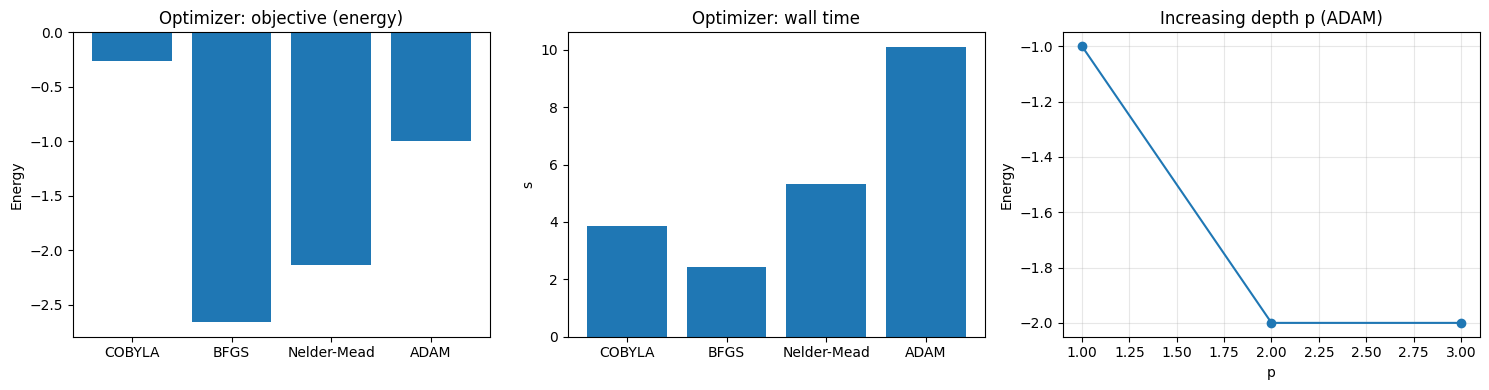

In [67]:
%matplotlib inline

labels = ['COBYLA', 'BFGS', 'Nelder-Mead', 'ADAM']
opt_energies = [res_cobyla.energy, res_bfgs.energy, res_nm.energy, res_adam.energy]
opt_times = [res_cobyla.wall_time, res_bfgs.wall_time, res_nm.wall_time, res_adam.wall_time]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.bar(labels, opt_energies)
ax1.set_title('Optimizer: objective (energy)')
ax1.set_ylabel('Energy')

ax2.bar(labels, opt_times)
ax2.set_title('Optimizer: wall time')
ax2.set_ylabel('s')

ax3.plot(depths, energies, marker='o')
ax3.set_title('Increasing depth p (ADAM)')
ax3.set_xlabel('p')
ax3.set_ylabel('Energy')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Examples / full demo cases

If you want to try a more complete “kitchen sink” set of configurations (different backends, ansatz choices, and data-encoding choices), run the example notebook:

- `openvqa/examples/qaoa_demo.ipynb`

Recommended things to try inside that example notebook:

- **Ansatz**: Qiskit (`RealAmplitudes`, `EfficientSU2`, `TwoLocal`) vs PennyLane (`StronglyEntanglingLayers`, `BasicEntanglerLayers`, `RandomLayers`).
- **Feature map / embedding**: Qiskit feature maps (`PauliFeatureMap`, `ZZFeatureMap`, `ZFeatureMap`) vs PennyLane embeddings (`AngleEmbedding`, `AmplitudeEmbedding`, `BasisEmbedding`, `DisplacementEmbedding`).
- **Optimizer**: compare `cobyla`, `bfgs`, `nelder-mead`, `adam` with the same graph.
- **Depth**: sweep `p = 1, 2, 3, 4` and scale `max_iterations` with `p`.
- **Restarts**: repeat runs with multiple random initial points and keep the best energy.